'pial_mesh.coordinates' shape: (2562, 3)
'pial_mesh.faces' shape: (5120, 3)


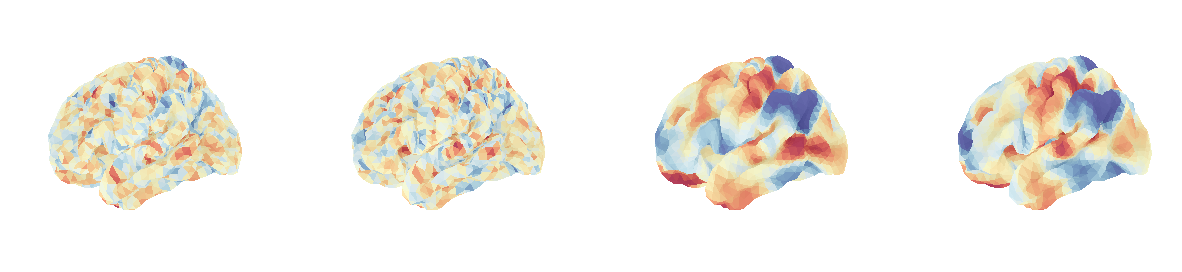

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from nilearn import datasets, plotting
from nilearn.surface import load_surf_mesh

from src import surface

fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage4")
surface_mesh = load_surf_mesh(fsaverage.pial_left)
print(
    f"'pial_mesh.coordinates' shape: {surface_mesh.coordinates.shape}",
    f"'pial_mesh.faces' shape: {surface_mesh.faces.shape}",
    sep="\n",
)

# initialize parameters
rng = np.random.default_rng(seed=0)
n_vertices = surface_mesh.coordinates.shape[0]

# simulate map0 and map1 with correlation rho
rho = 0.6
maps = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=n_vertices)
maps = maps - maps.mean(axis=0)  # mean center
maps_smoothed = surface.smooth_surface_data(surface_mesh, maps, iterations=10, match="dist")

# plot map0 and map1
fig, axs = plt.subplots(1, 4, figsize=(15, 4), subplot_kw=dict(projection="3d"))
plot_surf_kwargs = dict(bg_map=fsaverage.sulc_left, bg_on_data=True, cmap="RdYlBu", vmin=-2, vmax=2)

plotting.plot_surf(surface_mesh, maps[:, 0], axes=axs[0], **plot_surf_kwargs)
plotting.plot_surf(surface_mesh, maps[:, 1], axes=axs[1], **plot_surf_kwargs)
plotting.plot_surf(surface_mesh, maps_smoothed[:, 0], axes=axs[2], **plot_surf_kwargs)
plotting.plot_surf(surface_mesh, maps_smoothed[:, 1], axes=axs[3], **plot_surf_kwargs)
pass  # stop from double-plotting

In [2]:
# !!! 30sec runtime !!!
def estimate_rho_hat(x1, x2):
    """Estimate the sample correlation (`rho hat`) between two vectors."""
    return x1.dot(x2) / x1.shape[0]


# initialize simulation results
n_simulations = 1000
rhos = [0.0, 0.3, 0.6, 0.9]
simulations = {
    f"{rho}_{suffix}": np.zeros(n_simulations)
    for rho in rhos
    for suffix in ["maps", "maps-smoothed"]
}

for rho in rhos:
    for i in range(n_simulations):
        # generate maps
        maps = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=n_vertices)
        maps = maps - maps.mean(axis=0)  # mean center
        maps_smoothed = surface.smooth_surface_data(surface_mesh, maps, iterations=10, match="dist")

        # estimate rho hats
        rho_hat = estimate_rho_hat(maps[:, 0], maps[:, 1])
        rho_hat_smoothed = estimate_rho_hat(maps_smoothed[:, 0], maps_smoothed[:, 1])

        # save estimates for plotting
        simulations[f"{rho}_maps"][i] = rho_hat
        simulations[f"{rho}_maps-smoothed"][i] = rho_hat_smoothed

Text(0.5, 1.0, '$\\hat{\\rho}_\\text{smoothed}$')

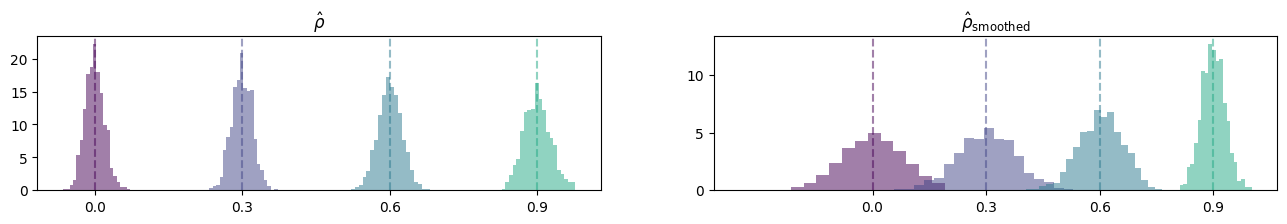

In [3]:
# plot simulations
colors = plt.cm.viridis(np.linspace(0, 1, len(rhos) + 2))
hist_kwargs = dict(bins=20, alpha=0.5, density=True)
vline_kwargs = dict(ls="--", alpha=0.5)

fig, axs = plt.subplots(1, 2, figsize=(16, 2))
for rho, color in zip(rhos, colors):
    axs[0].hist(simulations[f"{rho}_maps"], color=color, **hist_kwargs)
    axs[0].axvline(rho, color=color, **vline_kwargs)
    axs[1].hist(simulations[f"{rho}_maps-smoothed"], color=color, **hist_kwargs)
    axs[1].axvline(rho, color=color, **vline_kwargs)

axs[0].set_xticks(rhos)
axs[1].set_xticks(rhos)
axs[0].set_title(r"$\hat{\rho}$")
axs[1].set_title(r"$\hat{\rho}_\text{smoothed}$")